# Trade-Flow Benchmark — Full Comparison Walkthrough

**Reading key, assumed throughout this notebook** (worth checking this matches your intent before trusting the numbers below):
- **"no-GDELT GAT" / "GAT" / "EdgeGAT"** = GAT without GDELT / GAT with GDELT (all fusion+scoring variants) / EdgeGAT_full (all fusion+combo variants) -- `results_v2_chips_reproduced.csv` has no RF/TabTF/GCN rows at all, so this is the only reading that matches the data.
- **"chips"** = `results_v2_chips_reproduced.csv` -- a plain (no per-product head) model trained *only* on `chips.parquet`.
- **"all products (the first approach)"** = `results_perproduct_head.csv` -- your *first* per-product-head experiment (shared backbone + per-heading weights, **no hierarchical shrinkage yet**), trained on the full `all_products_ready.parquet`. It only covers **4** configs (not the full 19), so sections 2/3 below show chips in full detail with this overlaid only where a matching config exists.
- **"multitask idea vs. classically putting all products at once"** = the already-computed `perproduct_vs_pooled.csv` (per-product head vs. a fully pooled model with no per-product mechanism at all).
- **"per-product head with shrinkage, HS 8541+8542, vs. old approach of chips"** = `results_shrinkage_head.csv`'s `HS_8541_8542_combined` slice vs. `results_v2_chips_reproduced.csv` -- the hierarchical-shrinkage version, evaluated on exactly your chips codes, against the dedicated chips-only model.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'savefig.facecolor': '#ffffff',
    'axes.edgecolor': '#000000', 'axes.labelcolor': '#000000',
    'text.color': '#000000', 'xtick.color': '#000000', 'ytick.color': '#000000',
    'axes.grid': True, 'grid.color': '#000000', 'grid.alpha': 0.15, 'font.size': 10,
})
BLUE, ORANGE, POS, NEG, PURPLE, GRAY = '#4c8fbd', '#c47f3e', '#2ca02c', '#d62728', '#9467bd', '#888888'

def load_v2(path):
    r = pd.read_csv(path)
    r = r.drop_duplicates(['model','fusion','scoring','gdelt','risk_level','agg_mode','missing','tranche'], keep='last')
    return r[r.tranche == 'all']

GRIDS = '../../results/grids/'
COMPARISONS = '../../results/comparisons/'
FEATURE_IMPORTANCE = '../../results/feature_importance/'

chips           = load_v2(GRIDS + 'results_v2_chips_reproduced.csv')
medical         = load_v2(GRIDS + 'results_v2_medical.csv')
vehicles        = load_v2(GRIDS + 'results_v2_vehicles.csv')
oil             = load_v2(GRIDS + 'results_v2_oil.csv')
electronics     = load_v2(GRIDS + 'results_v2_electronics_authoritative.csv')  # renamed during the repo reorg (was results_v2_electro_v2.csv)
first_approach  = pd.read_csv(GRIDS + 'results_perproduct_head.csv')
fa_overall      = first_approach[first_approach.scope == 'overall'].copy()
fa_overall['is_gat'] = fa_overall.model.str.startswith('GAT')
shrink          = pd.read_csv(GRIDS + 'results_shrinkage_head.csv')
mvp             = pd.read_csv(COMPARISONS + 'perproduct_vs_pooled.csv')
fi_chips        = pd.read_csv(FEATURE_IMPORTANCE + 'feature_importance_chips.csv')

print('all files loaded OK')

all files loaded OK


### Mosaic helper

Every grouped comparison below can be viewed through log-R², Spearman rho, or SMAPE
(whichever are available in the underlying files for that particular comparison) --
one subplot per metric, same groups/bars in each, so you can pick whichever panel fits
best in the paper and still have the others on hand.

In [3]:
def plot_metric_mosaic(index, series, metrics, metric_labels=None, title_prefix='',
                       orientation='horizontal', panel_size=(6, 6), value_fmt=None, rotation=30):
    """index: list of category/feature labels
    series: {series_label: {metric_name: array-like aligned with index}}
    metrics: candidate metric names -- only ones present in EVERY series are actually plotted
    Each metric gets its OWN independent figure (not a shared subplot panel), so each
    can be selected and saved on its own.
    """
    metric_labels = metric_labels or {}
    available = [m for m in metrics if all(m in s for s in series.values())]
    if not available:
        print(f'[skip mosaic] none of {metrics} available in all series for "{title_prefix}"')
        return []
    palette = [BLUE, ORANGE, PURPLE, GRAY]
    n_series = len(series)
    x = np.arange(len(index)); w = 0.8 / n_series
    figs = []
    for metric in available:
        fig, ax = plt.subplots(figsize=panel_size)
        for si, (label, data) in enumerate(series.items()):
            vals = np.asarray(data[metric], dtype=float)
            off = -w*n_series/2 + w*(si + 0.5)
            if orientation == 'vertical':
                ax.bar(x + off, vals, w, label=label, color=palette[si % len(palette)])
            else:
                ax.barh(x + off, vals, w, label=label, color=palette[si % len(palette)])
            if value_fmt:
                for xi, v in zip(x + off, vals):
                    if orientation == 'vertical':
                        ax.text(xi, v, value_fmt.format(v), ha='center', va='bottom', fontsize=6)
                    else:
                        ax.text(v, xi, value_fmt.format(v), ha='left', va='center', fontsize=6)
        if orientation == 'vertical':
            ax.set_xticks(x); ax.set_xticklabels(index, rotation=rotation, ha='right', fontsize=8)
            ax.axhline(0, color='black', lw=.5)
        else:
            ax.set_yticks(x); ax.set_yticklabels(index, fontsize=8); ax.invert_yaxis()
            ax.axvline(0, color='black', lw=.5)
        ax.set_title(f'{title_prefix}\n{metric_labels.get(metric, metric)}', fontsize=10, fontweight='bold')
        if n_series > 1:
            ax.legend(fontsize=7, loc='best')
        fig.tight_layout()
        figs.append((fig, ax))
    return figs

METRIC_LABELS = {'log_r2': 'log-R² (higher = better)', 'spearman': 'Spearman ρ (higher = better)',
                 'smape': 'SMAPE % (lower = better)', 'log_mse': 'log-MSE (lower = better)'}

## 0. Does GDELT add value? (overall, across all 5 product categories, clean re-check)

Two comparisons, both using the same already-loaded per-category grids (`chips`/`medical`/`vehicles`/`oil`/`electronics`) -- no new files, no re-training:

1. **Naive group means** -- average log-R² with GDELT present vs. absent, no config matching. Quick sanity check, but confounded if different configs happen to dominate each group.
2. **Paired comparison** (the one that actually answers the question) -- same exact config (model/fusion/risk_level/agg_mode/missing/category), only the presence of GDELT differs. Shown both as the mean-across-GDELT-variants (honest, conservative) and best-GDELT-variant (upper bound -- don't over-read this one, it's cherry-picked by construction).

Loaded 68 rows across 5 categories

=== naive group means (no config-matching) ===
                          mean     std  count
category    gdelt_flag                       
chips       False       0.3140     NaN      1
            True        0.2699  0.0513     18
electronics False       0.3842  0.1701      4
            True       -1.8174  4.7825     24
medical     False       0.2395     NaN      1
            True        0.2820  0.0593      6
oil         False       0.2534     NaN      1
            True        0.3208  0.0211      6
vehicles    False       0.3027     NaN      1
            True        0.2892  0.0523      6

=== paired comparison (same config, GDELT vs no-GDELT) ===
Empty DataFrame
Columns: [model, fusion, risk_level, agg_mode, missing, category, no_gdelt, mean_gdelt_variant, best_gdelt_variant, delta_mean, delta_best]
Index: []

Honest comparison (mean-across-GDELT-variants): GDELT helps in 0/0 matched configs, mean delta = +nan
Upper-bound comparison (best GDELT v

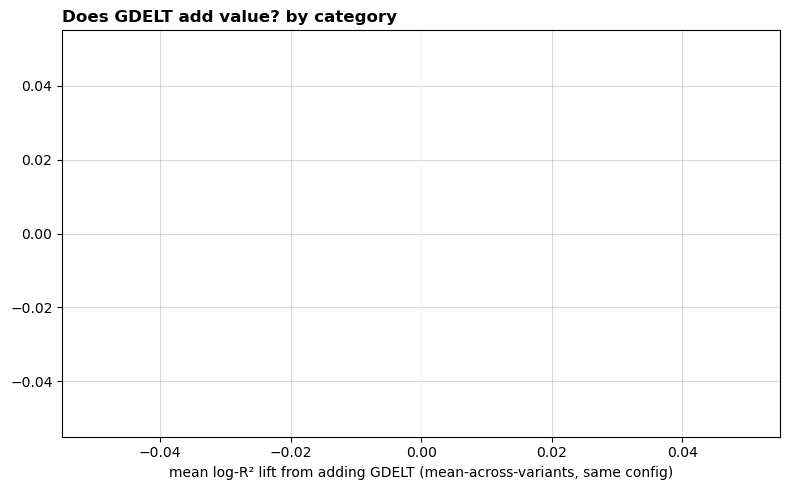

In [4]:
def normalize_gdelt_flag(s):
    if s.dtype == bool:
        return s
    return s.astype(str).str.lower().isin(['true', '1', 'yes', 'keepall', 'topk'])

CATEGORY_DFS = {'chips': chips, 'medical': medical, 'vehicles': vehicles, 'oil': oil, 'electronics': electronics}
all_cat = []
for cat, df in CATEGORY_DFS.items():
    d = df.copy()
    d['gdelt_flag'] = normalize_gdelt_flag(d['gdelt'])
    d['category'] = cat
    all_cat.append(d)
combined = pd.concat(all_cat, ignore_index=True)
print(f'Loaded {len(combined)} rows across {len(CATEGORY_DFS)} categories')

# 1. naive group means
naive = combined.groupby(['category', 'gdelt_flag'])['log_r2'].agg(['mean', 'std', 'count']).round(4)
print('\n=== naive group means (no config-matching) ===')
print(naive.to_string())

# 2. paired comparison -- same config, only GDELT presence differs
match_cols = ['model', 'fusion', 'risk_level', 'agg_mode', 'missing', 'category']
no_gdelt = combined[~combined.gdelt_flag].set_index(match_cols)['log_r2']
gdelt_rows = combined[combined.gdelt_flag].groupby(match_cols)['log_r2']
mean_gdelt = gdelt_rows.mean()   # primary, honest comparison
best_gdelt = gdelt_rows.max()    # upper-bound context only

paired = pd.concat([
    no_gdelt.rename('no_gdelt'),
    mean_gdelt.rename('mean_gdelt_variant'),
    best_gdelt.rename('best_gdelt_variant'),
], axis=1).dropna()
paired['delta_mean'] = paired['mean_gdelt_variant'] - paired['no_gdelt']
paired['delta_best'] = paired['best_gdelt_variant'] - paired['no_gdelt']

print('\n=== paired comparison (same config, GDELT vs no-GDELT) ===')
print(paired.reset_index().round(4).to_string(index=False))

n_pos_mean = (paired['delta_mean'] > 0).sum()
print(f"\nHonest comparison (mean-across-GDELT-variants): GDELT helps in {n_pos_mean}/{len(paired)} matched configs, "
      f"mean delta = {paired['delta_mean'].mean():+.4f}")
n_pos_best = (paired['delta_best'] > 0).sum()
print(f"Upper-bound comparison (best GDELT variant): {n_pos_best}/{len(paired)} configs, "
      f"mean delta = {paired['delta_best'].mean():+.4f}  (don't over-read this one -- it's the best of several tries)")

per_cat_delta = paired.reset_index().groupby('category')['delta_mean'].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
colors = [NEG if v < 0 else POS for v in per_cat_delta]
ax.barh(per_cat_delta.index, per_cat_delta.values, color=colors)
ax.axvline(0, color='w', lw=.6)
ax.set_xlabel('mean log-R² lift from adding GDELT (mean-across-variants, same config)')
ax.set_title('Does GDELT add value? by category', loc='left', fontweight='bold')
fig.tight_layout()


### 0b. Same GDELT-lift comparison, across metrics

[(<Figure size 600x600 with 1 Axes>,
  <Axes: title={'center': '0b. Does GDELT add value, by category -- log-R² / spearman / smape\nlog-R² (higher = better)'}>),
 (<Figure size 600x600 with 1 Axes>,
  <Axes: title={'center': '0b. Does GDELT add value, by category -- log-R² / spearman / smape\nSpearman ρ (higher = better)'}>),
 (<Figure size 600x600 with 1 Axes>,
  <Axes: title={'center': '0b. Does GDELT add value, by category -- log-R² / spearman / smape\nSMAPE % (lower = better)'}>)]

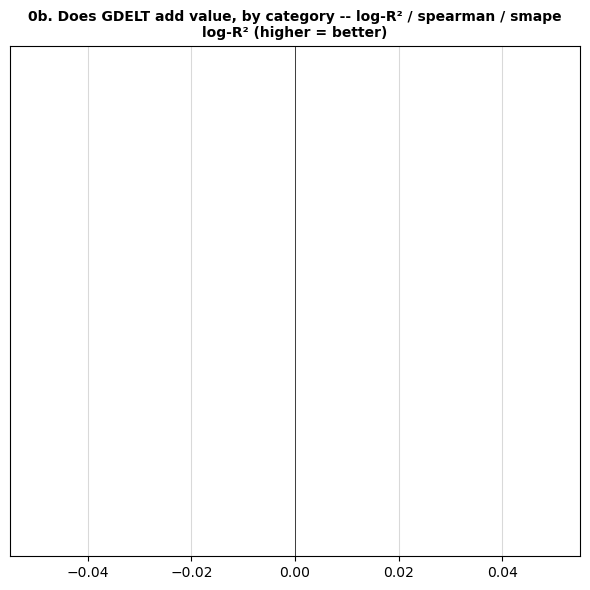

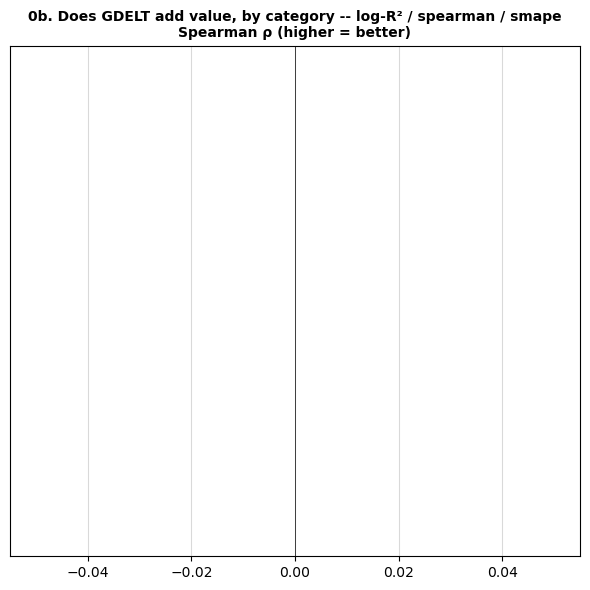

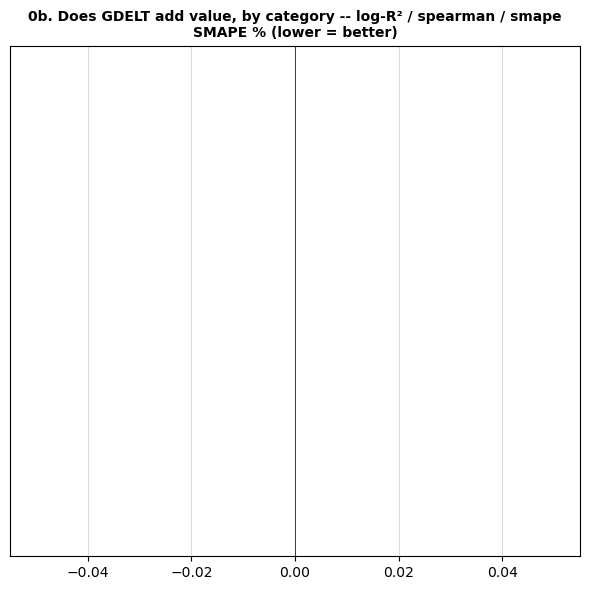

In [5]:
cat_series = {
    'log-R² lift': {}, 'spearman lift': {}, 'smape lift (negated: lower smape = better)': {}
}
per_cat = {}
for metric, mult in [('log_r2', 1), ('spearman', 1), ('smape', -1)]:
    no_g = combined[~combined.gdelt_flag].set_index(match_cols)[metric]
    g_mean = combined[combined.gdelt_flag].groupby(match_cols)[metric].mean()
    d = (g_mean - no_g).dropna()
    if mult == -1:
        d = -d   # so 'positive = GDELT helped' holds for smape too (lower smape is better)
    per_cat[metric] = d.reset_index().groupby('category')[metric].mean() if metric in d.reset_index().columns else None

per_cat_df = combined.copy()
lift_rows = {}
for metric, mult in [('log_r2', 1), ('spearman', 1), ('smape', -1)]:
    no_g = combined[~combined.gdelt_flag].set_index(match_cols)[metric]
    g_mean = combined[combined.gdelt_flag].groupby(match_cols)[metric].mean()
    d = (mult * (g_mean - no_g)).dropna().reset_index()
    lift_rows[metric] = d.groupby('category')[metric].mean()

lift_df = pd.DataFrame(lift_rows).sort_values('log_r2')
plot_metric_mosaic(
    lift_df.index.tolist(), {'GDELT lift': {m: lift_df[m] for m in lift_df.columns}},
    metrics=['log_r2', 'spearman', 'smape'], metric_labels=METRIC_LABELS,
    title_prefix='0b. Does GDELT add value, by category -- log-R² / spearman / smape',
    orientation='horizontal', value_fmt='{:.3f}'
)

## 1. Overall: no-GDELT GAT vs. GAT+GDELT vs. EdgeGAT_full

Best achievable log-R² in each of the three buckets, for **chips** (dedicated model) and **all products (first approach)**.

,chips (dedicated),all products (first approach)
no-GDELT GAT,0.3140,0.324593
GAT+GDELT (best),0.3546,0.319752
EdgeGAT_full (best),0.3083,0.341239


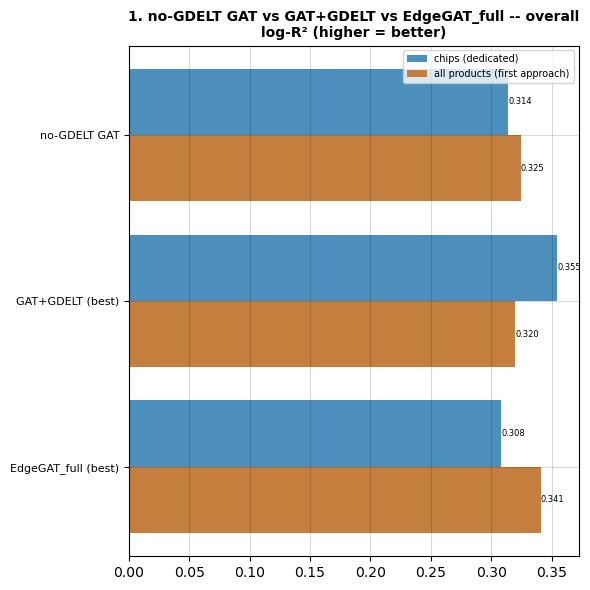

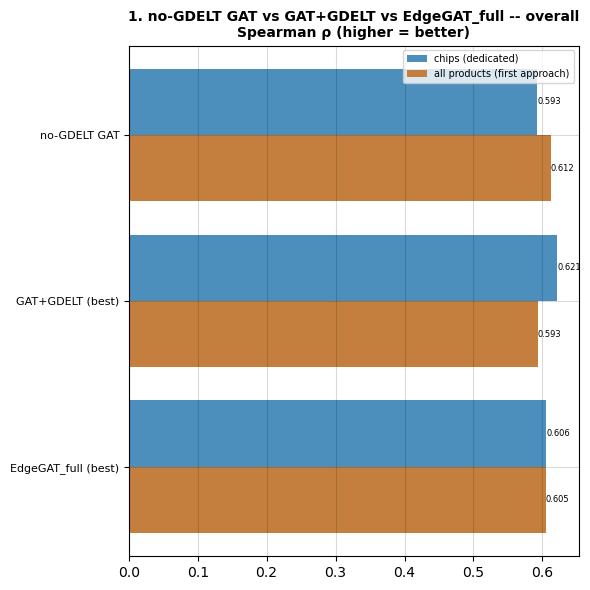

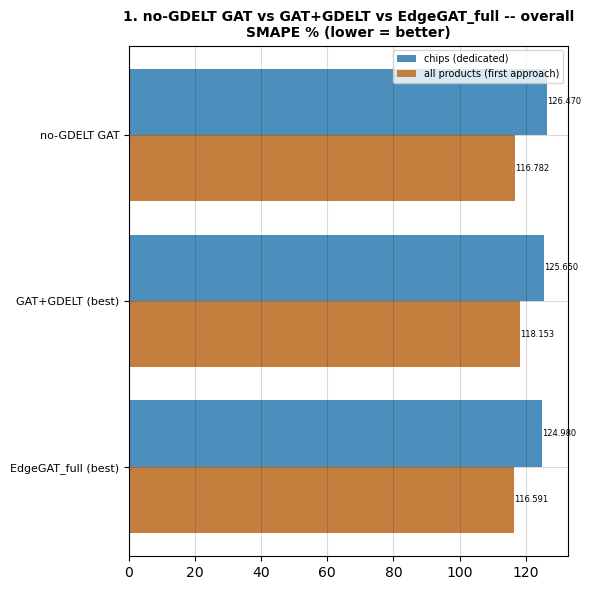

In [6]:
def bucket_metrics_chips(df, metric):
    no_gdelt = df[(df.model=='GAT') & (df.scoring=='none')][metric]
    gat_gdelt = df[(df.model=='GAT') & (df.scoring!='none')][metric]
    edge = df[df.model=='EdgeGAT_full'][metric]
    # for smape lower is better, so 'best' means min there, max everywhere else
    best = (lambda s: s.min()) if metric == 'smape' else (lambda s: s.max())
    return {'no-GDELT GAT': best(no_gdelt) if len(no_gdelt) else np.nan,
            'GAT+GDELT (best)': best(gat_gdelt) if len(gat_gdelt) else np.nan,
            'EdgeGAT_full (best)': best(edge) if len(edge) else np.nan}

def bucket_metrics_first_approach(fa, metric):
    no_gdelt = fa[fa.model=='GAT_first_none_perproduct'][metric]
    gat_gdelt = fa[(fa.is_gat) & (fa.model!='GAT_first_none_perproduct')][metric]
    edge = fa[~fa.is_gat][metric]
    best = (lambda s: s.min()) if metric == 'smape' else (lambda s: s.max())
    return {'no-GDELT GAT': best(no_gdelt) if len(no_gdelt) else np.nan,
            'GAT+GDELT (best)': best(gat_gdelt) if len(gat_gdelt) else np.nan,
            'EdgeGAT_full (best)': best(edge) if len(edge) else np.nan}

bucket_index = ['no-GDELT GAT', 'GAT+GDELT (best)', 'EdgeGAT_full (best)']
series_1 = {
    'chips (dedicated)': {m: pd.Series(bucket_metrics_chips(chips, m)).reindex(bucket_index) for m in ['log_r2','spearman','smape']},
    'all products (first approach)': {m: pd.Series(bucket_metrics_first_approach(fa_overall, m)).reindex(bucket_index) for m in ['log_r2','spearman','smape']},
}
plot_metric_mosaic(bucket_index, series_1, metrics=['log_r2','spearman','smape'], metric_labels=METRIC_LABELS,
                    title_prefix='1. no-GDELT GAT vs GAT+GDELT vs EdgeGAT_full -- overall', value_fmt='{:.3f}')

buckets = pd.DataFrame({
    'chips (dedicated)': bucket_metrics_chips(chips, 'log_r2'),
    'all products (first approach)': bucket_metrics_first_approach(fa_overall, 'log_r2'),
})
buckets

## 2. GAT versions — detailed comparison

All 6 GDELT-enabled GAT variants for chips (keepall/topk × concat/blend/attention), plus the no-GDELT baseline. The all-products first-approach experiment only ever trained 2 GAT configs (no-GDELT and topk/concat), so it's overlaid as reference points, not a full second bar group.

,label,fusion,scoring,log_r2,spearman
20,topk/blend,blend,topk,0.3546,0.6141
24,topk/attention,attention,topk,0.3500,0.6214
4,keepall/concat,concat,keepall,0.3330,0.5974
8,keepall/blend,blend,keepall,0.3161,0.5880
0,none,none,none,0.3140,0.5925
16,topk/concat,concat,topk,0.3118,0.6102
12,keepall/attention,attention,keepall,0.2599,0.5828


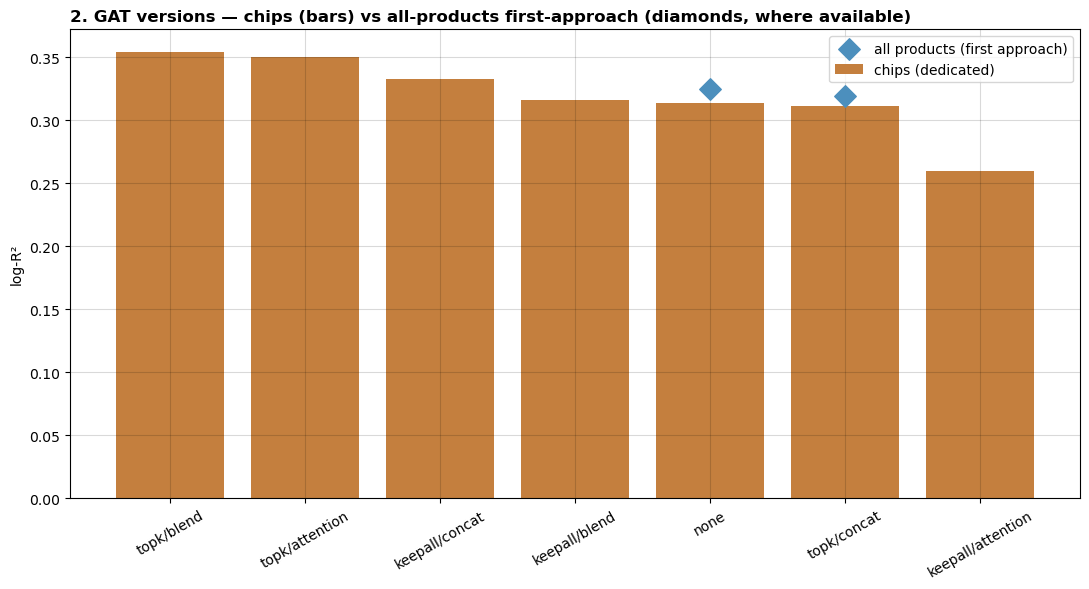

In [7]:
gat_chips = chips[chips.model=='GAT'].copy()
gat_chips['label'] = gat_chips.apply(lambda r: 'none' if r.scoring=='none' else f'{r.scoring}/{r.fusion}', axis=1)
gat_chips = gat_chips.sort_values('log_r2', ascending=False)

fa_gat = fa_overall[fa_overall.is_gat].copy()
fa_gat_map = {'GAT_first_none_perproduct': 'none', 'GAT_first_topk_perproduct': 'topk/concat'}
fa_gat['label'] = fa_gat['model'].map(fa_gat_map)

fig, ax = plt.subplots(figsize=(11,6))
colors = [POS if v>=0 else NEG for v in gat_chips['log_r2']]
ax.bar(gat_chips['label'], gat_chips['log_r2'], color=ORANGE, label='chips (dedicated)')
for _, row in fa_gat.iterrows():
    if row['label'] in gat_chips['label'].values:
        xi = list(gat_chips['label']).index(row['label'])
        ax.scatter(xi, row['log_r2'], color=BLUE, s=120, zorder=5, marker='D',
                   label='all products (first approach)' if xi==list(gat_chips['label']).index(row['label']) else None)
ax.set_ylabel('log-R²'); ax.set_title('2. GAT versions — chips (bars) vs all-products first-approach (diamonds, where available)', loc='left', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
fig.tight_layout()

gat_chips[['label','fusion','scoring','log_r2','spearman']]

## 3. EdgeGAT_full versions — detailed comparison

All 12 EdgeGAT_full variants for chips (4 scorer combos × 3 fusions). All-products first-approach only trained 2 of these (attention/ka_ka, blend/tk_tk), overlaid as reference points.

,label,fusion,scoring,log_r2,spearman
32,ka_ka/blend,blend,ka_ka,0.3083,0.6060
44,tk_tk/blend,blend,tk_tk,0.2941,0.5681
36,ka_ka/attention,attention,ka_ka,0.2719,0.5510
48,tk_tk/attention,attention,tk_tk,0.2698,0.5788
60,ka_tk/attention,attention,ka_tk,0.2496,0.5322
72,tk_ka/attention,attention,tk_ka,0.2421,0.5490
52,ka_tk/concat,concat,ka_tk,0.2369,0.5261
28,ka_ka/concat,concat,ka_ka,0.2328,0.5195
40,tk_tk/concat,concat,tk_tk,0.2284,0.5283
64,tk_ka/concat,concat,tk_ka,0.2217,0.5350


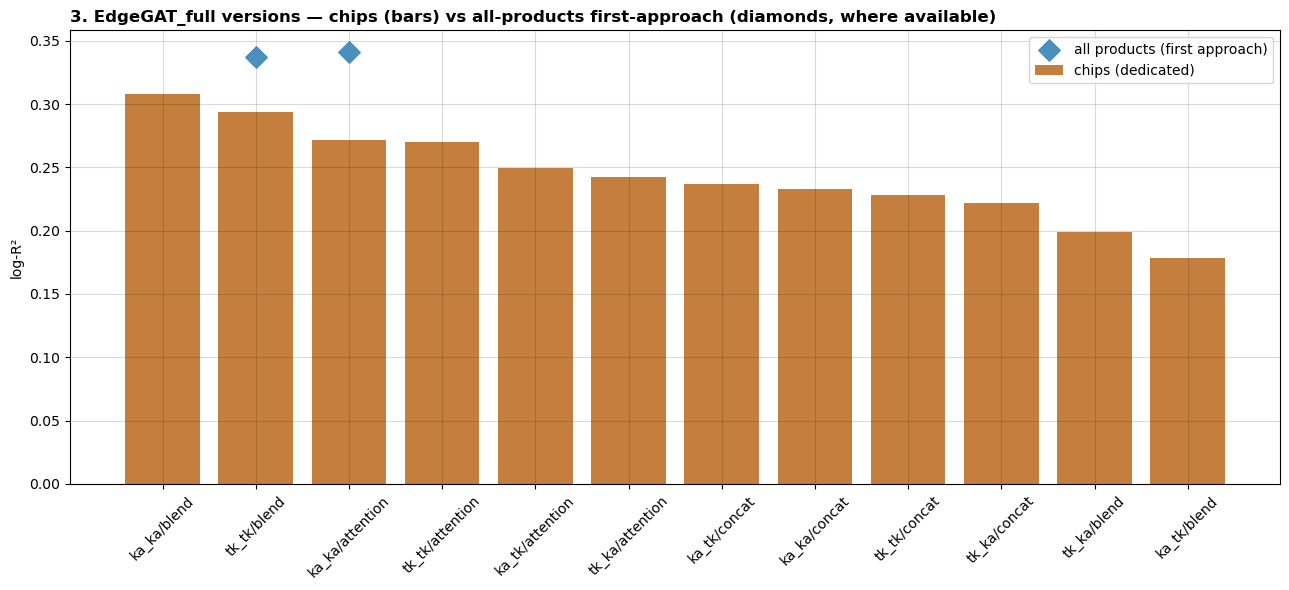

In [8]:
edge_chips = chips[chips.model=='EdgeGAT_full'].copy()
edge_chips['label'] = edge_chips['scoring'] + '/' + edge_chips['fusion']
edge_chips = edge_chips.sort_values('log_r2', ascending=False)

fa_edge = fa_overall[~fa_overall.is_gat].copy()
fa_edge_map = {'EdgeGAT_full_attention_ka_ka_perproduct': 'ka_ka/attention',
               'EdgeGAT_full_blend_tk_tk_perproduct': 'tk_tk/blend'}
fa_edge['label'] = fa_edge['model'].map(fa_edge_map)

fig, ax = plt.subplots(figsize=(13,6))
ax.bar(edge_chips['label'], edge_chips['log_r2'], color=ORANGE, label='chips (dedicated)')
plotted = set()
for _, row in fa_edge.iterrows():
    if row['label'] in edge_chips['label'].values:
        xi = list(edge_chips['label']).index(row['label'])
        lbl = 'all products (first approach)' if 'fa' not in plotted else None
        ax.scatter(xi, row['log_r2'], color=BLUE, s=120, zorder=5, marker='D', label=lbl)
        plotted.add('fa')
ax.set_ylabel('log-R²'); ax.set_title('3. EdgeGAT_full versions — chips (bars) vs all-products first-approach (diamonds, where available)', loc='left', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.tight_layout()

edge_chips[['label','fusion','scoring','log_r2','spearman']]

## 4. Feature importance — chips only

Permutation importance averaged across every model that tested each feature (from `feature_importance_chips.csv`). `refYear` excluded — constant in the 2023-only eval set, so this test can't measure it.

,mean,std,count
feature_clean,,,
gdpcap_o,0.1687,0.0822,6
score_mean,0.1443,0.1791,5
tone_mean,0.1408,0.1079,5
pop_o,0.1034,0.0502,6
active_months,0.0767,0.0614,5
events_total,0.0685,0.0778,5
goldstein_wmean,0.0657,0.0449,5
dist,0.0448,0.0516,6
score_vol,0.0364,0.0620,5


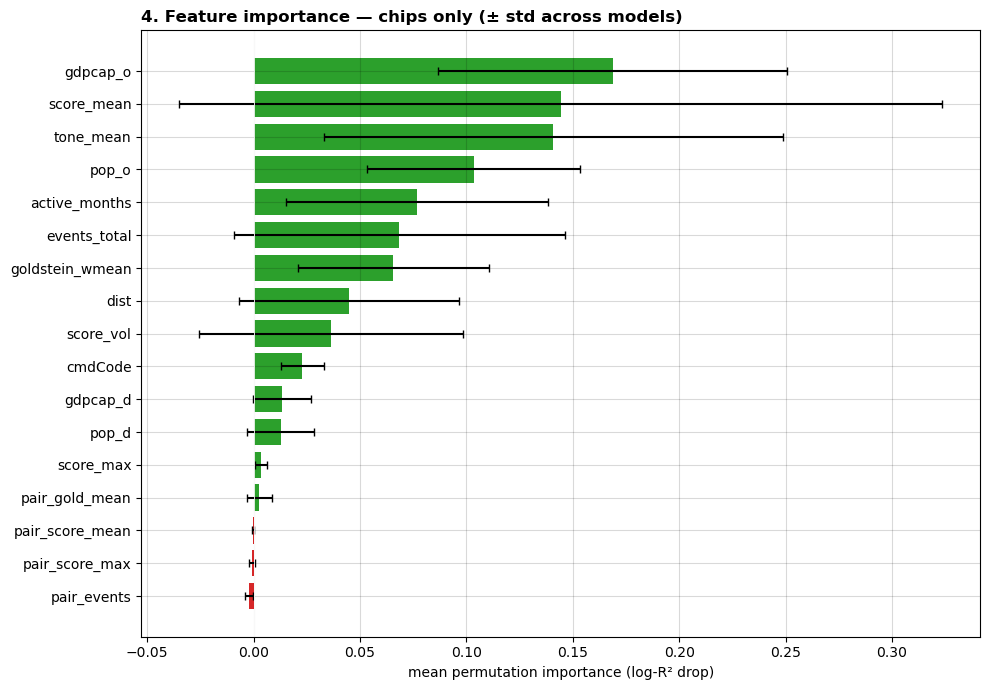

In [9]:
fi = fi_chips.copy()
fi['feature_clean'] = fi['feature'].apply(lambda f: f.split(':', 1)[-1] if ':' in f else f)
fi = fi[fi.feature_clean != 'refYear']
agg = fi.groupby('feature_clean')['importance_log_r2'].agg(['mean','std','count']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10,7))
colors = [POS if v>=0 else NEG for v in agg['mean']]
ax.barh(agg.index, agg['mean'], xerr=agg['std'], color=colors, capsize=3)
ax.axvline(0, color='w', lw=.6)
ax.set_xlabel('mean permutation importance (log-R² drop)')
ax.set_title('4. Feature importance — chips only (± std across models)', loc='left', fontweight='bold')
ax.invert_yaxis()
fig.tight_layout()

agg.round(4)

## 5. Products independently vs. all products (pooled)

Best log-R² among the 4 configs shared by every source (`GAT` no-GDELT, `GAT` concat/topk, `EdgeGAT_full` attention/ka_ka, `EdgeGAT_full` blend/tk_tk) — the only 4 configs `all products (first approach)` actually has, so this is the fair common ground across all 6 sources.

,best_of_shared4
vehicles,0.367700
medical,0.357900
all products (per-product head),0.341239
oil,0.333100
chips,0.314000
electronics,0.308400
all products (classical pooled),0.169200


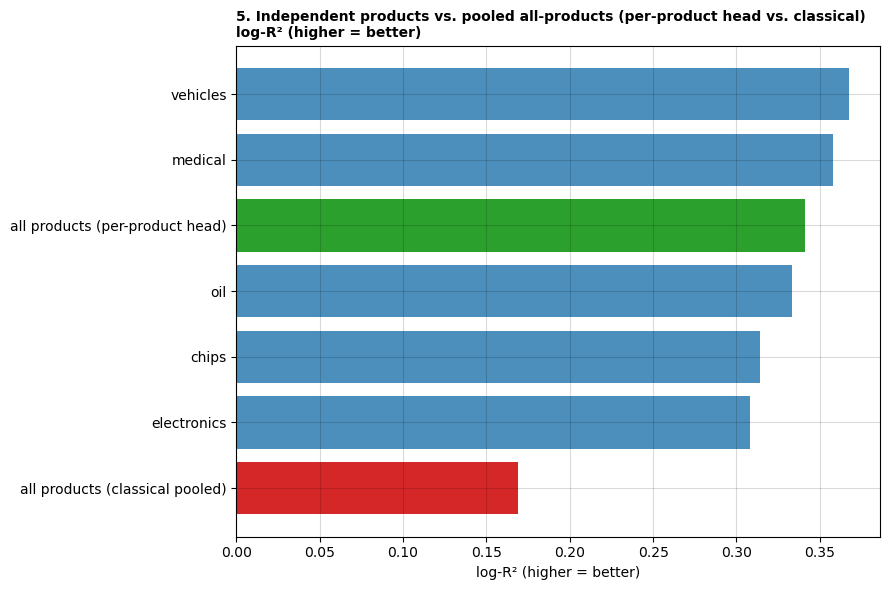

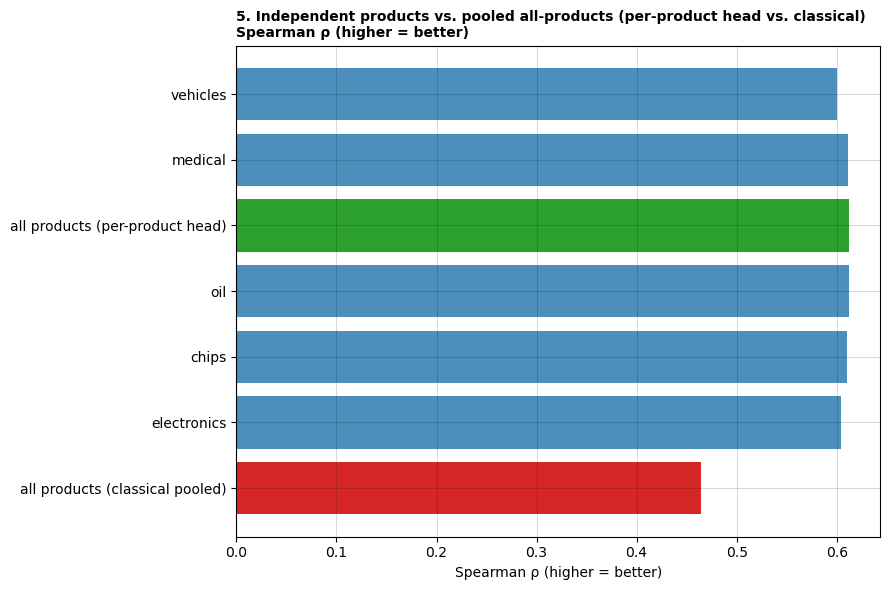

In [10]:
SHARED4 = [('GAT','none','none'), ('GAT','concat','topk'),
           ('EdgeGAT_full','attention','ka_ka'), ('EdgeGAT_full','blend','tk_tk')]
FA_NAMES = {('GAT','none','none'): 'GAT_first_none_perproduct',
            ('GAT','concat','topk'): 'GAT_first_topk_perproduct',
            ('EdgeGAT_full','attention','ka_ka'): 'EdgeGAT_full_attention_ka_ka_perproduct',
            ('EdgeGAT_full','blend','tk_tk'): 'EdgeGAT_full_blend_tk_tk_perproduct'}
MVP_NAMES = {('GAT','none','none'): 'GAT no-GDELT',
             ('GAT','concat','topk'): 'GAT concat/topk',
             ('EdgeGAT_full','attention','ka_ka'): 'EdgeGAT_full attn/ka_ka',
             ('EdgeGAT_full','blend','tk_tk'): 'EdgeGAT_full blend/tk_tk'}

categories = {'medical': medical, 'vehicles': vehicles, 'oil': oil, 'electronics': electronics, 'chips': chips}

def best_of_shared4(metric):
    rows = []
    for cat_name, df in categories.items():
        vals = []
        for m, f, s in SHARED4:
            sub = df[(df.model==m) & (df.fusion==f) & (df.scoring==s)]
            if len(sub): vals.append(sub.iloc[0][metric])
        rows.append({'category': cat_name, 'val': max(vals) if vals else np.nan})

    fa_vals = []
    for key, name in FA_NAMES.items():
        sub = fa_overall[fa_overall.model == name]
        if len(sub): fa_vals.append(sub.iloc[0][metric])
    rows.append({'category': 'all products (per-product head)', 'val': max(fa_vals) if fa_vals else np.nan})

    mvp_col = f'pooled_{metric}' if f'pooled_{metric}' in mvp.columns else None
    classical_vals = []
    if mvp_col:
        for key, label in MVP_NAMES.items():
            sub = mvp[mvp['model'] == label]
            if len(sub): classical_vals.append(sub.iloc[0][mvp_col])
    rows.append({'category': 'all products (classical pooled)', 'val': max(classical_vals) if classical_vals else np.nan})
    return pd.Series({r['category']: r['val'] for r in rows})

cat_order = None
series_5 = {}
for metric in ['log_r2', 'spearman']:   # smape not tracked for the classical-pooled baseline -- kept to metrics available everywhere
    s = best_of_shared4(metric)
    if cat_order is None:
        cat_order = s.sort_values(ascending=False).index.tolist()
    series_5.setdefault('best of shared4', {})[metric] = s.reindex(cat_order)

# per-bar coloring: red = classical pooled, green = per-product head, default blue otherwise
def bar_color(cat):
    if cat == 'all products (classical pooled)':
        return NEG
    if cat == 'all products (per-product head)':
        return POS
    return BLUE

bar_colors = [bar_color(c) for c in cat_order]
metric_titles = {'log_r2': 'log-R\u00b2 (higher = better)', 'spearman': 'Spearman \u03c1 (higher = better)'}

for metric in ['log_r2', 'spearman']:
    vals = series_5['best of shared4'][metric]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(cat_order, vals.reindex(cat_order), color=bar_colors)
    ax.axvline(0, color='black', lw=.5)
    ax.set_xlabel(metric_titles[metric])
    ax.set_title(f'5. Independent products vs. pooled all-products (per-product head vs. classical)\n{metric_titles[metric]}',
                 loc='left', fontweight='bold', fontsize=10)
    ax.invert_yaxis()
    fig.tight_layout()

cat_comp = pd.DataFrame({'best_of_shared4': series_5['best of shared4']['log_r2']}).sort_values('best_of_shared4', ascending=False)
cat_comp

## 6a. Multitask idea (per-product head) vs. classically pooling all products at once

Directly from `perproduct_vs_pooled.csv` — a fully pooled model (no per-product mechanism at all) vs. the first per-product-head version, same 4 configs, same all-products test set.

[note] smape was not logged for the per-heading experiment run (see PERHEAD dict in compare_perproduct_vs_pooled.py) -- only log-R² and spearman are available for this comparison.


,model,pooled_log_r2,perhead_log_r2,delta_log_r2
0,GAT no-GDELT,0.1114,0.324593,0.213193
1,GAT concat/topk,0.0643,0.319752,0.255452
2,EdgeGAT_full attn/ka_ka,-0.0074,0.341239,0.348639
3,EdgeGAT_full blend/tk_tk,0.1692,0.337088,0.167888


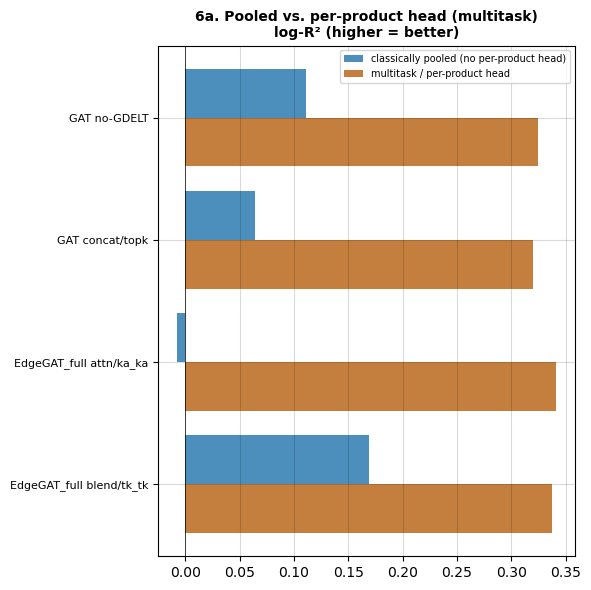

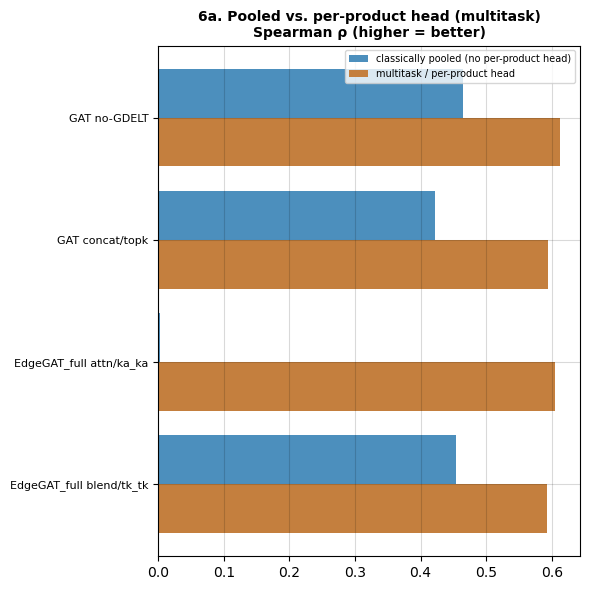

In [11]:
series_6a = {
    'classically pooled (no per-product head)': {'log_r2': mvp['pooled_log_r2'], 'spearman': mvp['pooled_spearman']},
    'multitask / per-product head': {'log_r2': mvp['perhead_log_r2'], 'spearman': mvp['perhead_spearman']},
}
plot_metric_mosaic(mvp['model'].tolist(), series_6a, metrics=['log_r2', 'spearman'], metric_labels=METRIC_LABELS,
                    title_prefix='6a. Pooled vs. per-product head (multitask)', rotation=15)
print('[note] smape was not logged for the per-heading experiment run (see PERHEAD dict in '
      'compare_perproduct_vs_pooled.py) -- only log-R\u00b2 and spearman are available for this comparison.')

mvp[['model','pooled_log_r2','perhead_log_r2','delta_log_r2']]

## 6b. Per-product head **with shrinkage**, HS 8541+8542 slice, vs. the old dedicated-chips approach

The final evolution: same idea as 6a, but with hierarchical shrinkage added, evaluated on exactly your chips codes (8541+8542) as part of the full pooled model, against the dedicated `chips.parquet`-only model.

**Caveat:** `n` differs between the two sides (≈378 for the pooled slice vs. 1,611 for the dedicated chips run) — different train/test construction, not the same exact rows. Directional evidence, not a bit-for-bit match.

Pooled + shrinkage beats the dedicated chips-only model in 18 / 19 configs.


,chips_log_r2,shrinkage_log_r2,delta,chips_n,shrinkage_n
label,,,,,
EdgeGAT_full_blend_tk_ka,0.1990,0.546469,0.347469,1611,378
EdgeGAT_full_blend_ka_tk,0.1784,0.478665,0.300265,1611,378
EdgeGAT_full_attention_ka_ka,0.2719,0.531968,0.260068,1611,378
EdgeGAT_full_concat_tk_tk,0.2284,0.486370,0.257970,1611,378
EdgeGAT_full_attention_tk_ka,0.2421,0.497694,0.255594,1611,378
EdgeGAT_full_attention_ka_tk,0.2496,0.482312,0.232712,1611,378
EdgeGAT_full_concat_ka_ka,0.2328,0.454388,0.221588,1611,378
GAT_first_keepall_attention,0.2599,0.467820,0.207920,1611,378
GAT_first_topk_concat,0.3118,0.504548,0.192748,1611,378


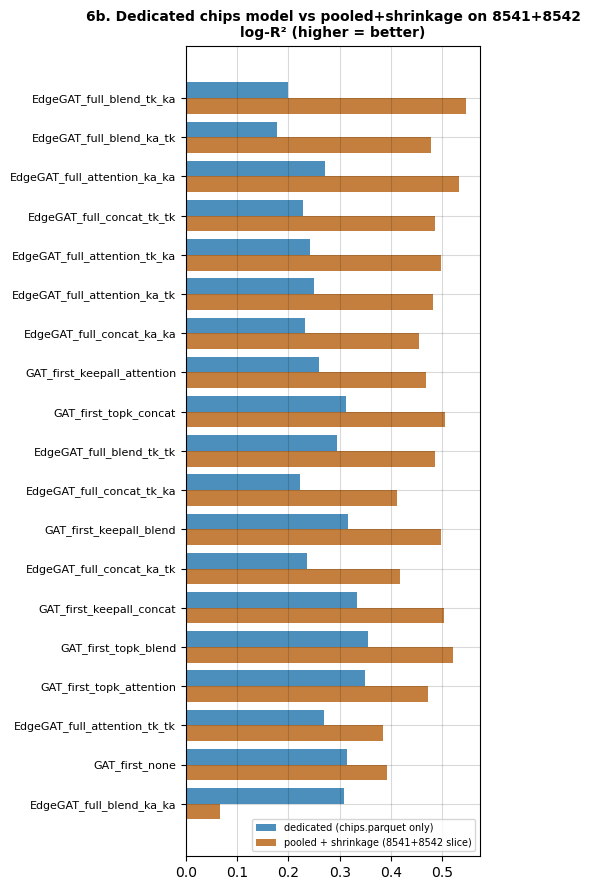

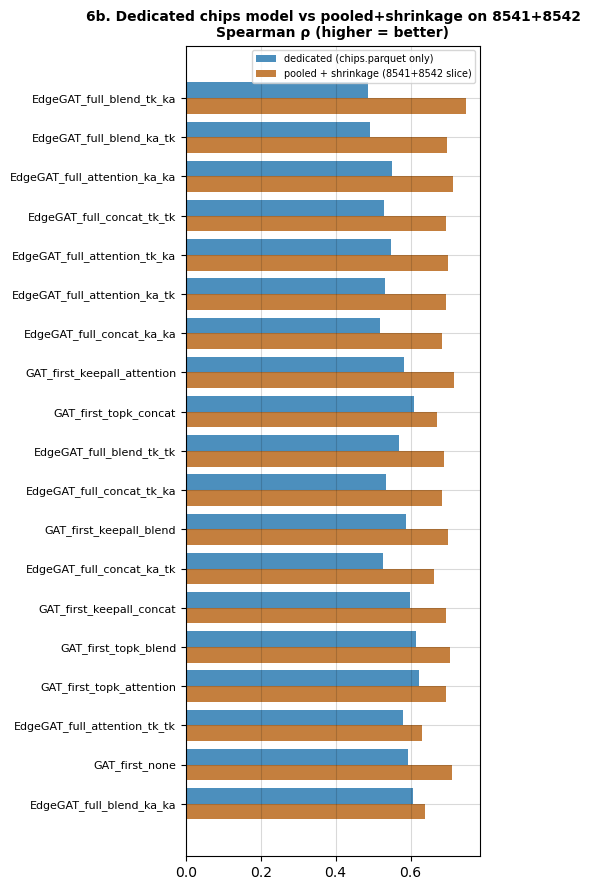

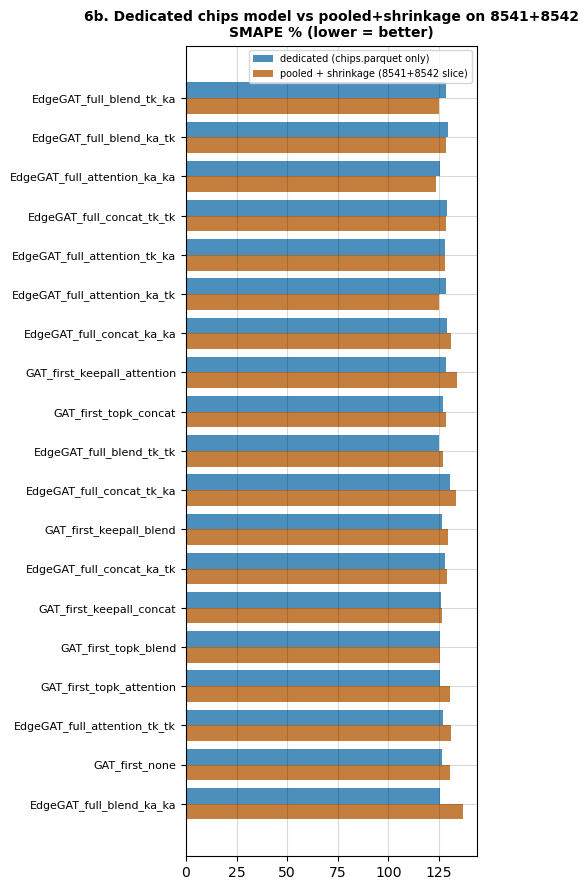

In [12]:
def parse_shrinkage_name(name):
    n = name.replace('_shrinkage', '')
    if n == 'GAT_first_none':
        return ('GAT', 'none', 'none')
    if n.startswith('GAT_first_'):
        rest = n[len('GAT_first_'):]
        scoring, fusion = rest.rsplit('_', 1)
        return ('GAT', fusion, scoring)
    if n.startswith('EdgeGAT_full_'):
        rest = n[len('EdgeGAT_full_'):]
        fusion, combo = rest.split('_', 1)
        return ('EdgeGAT_full', fusion, combo)
    raise ValueError(name)

combo_rows = shrink[shrink.scope == 'HS_8541_8542_combined']
rows = []
for _, row in combo_rows.iterrows():
    m, f, s = parse_shrinkage_name(row['model'])
    match = chips[(chips.model==m) & (chips.fusion==f) & (chips.scoring==s)]
    if len(match) == 0:
        continue
    match = match.iloc[0]
    rows.append({'label': row['model'].replace('_shrinkage',''),
                 'shrinkage_log_r2': row['log_r2'], 'chips_log_r2': match['log_r2'],
                 'shrinkage_spearman': row['spearman'], 'chips_spearman': match['spearman'],
                 'shrinkage_smape': row['smape'], 'chips_smape': match['smape'],
                 'shrinkage_n': row['n'], 'chips_n': match['n']})

comp = pd.DataFrame(rows).set_index('label')
comp['delta'] = comp['shrinkage_log_r2'] - comp['chips_log_r2']
comp = comp.sort_values('delta', ascending=False)
n_beat = (comp['delta'] > 0).sum()
print(f'Pooled + shrinkage beats the dedicated chips-only model in {n_beat} / {len(comp)} configs.')

series_6b = {
    'dedicated (chips.parquet only)': {'log_r2': comp['chips_log_r2'], 'spearman': comp['chips_spearman'], 'smape': comp['chips_smape']},
    'pooled + shrinkage (8541+8542 slice)': {'log_r2': comp['shrinkage_log_r2'], 'spearman': comp['shrinkage_spearman'], 'smape': comp['shrinkage_smape']},
}
plot_metric_mosaic(comp.index.tolist(), series_6b, metrics=['log_r2','spearman','smape'], metric_labels=METRIC_LABELS,
                    title_prefix='6b. Dedicated chips model vs pooled+shrinkage on 8541+8542',
                    orientation='horizontal', panel_size=(5, 9))

comp[['chips_log_r2','shrinkage_log_r2','delta','chips_n','shrinkage_n']]

,old approach (dedicated chips.parquet),"new approach (pooled + shrinkage, 8541+8542)"
no-GDELT GAT,0.3140,0.392105
GAT+GDELT (best),0.3546,0.520932
EdgeGAT_full (best),0.3083,0.546469


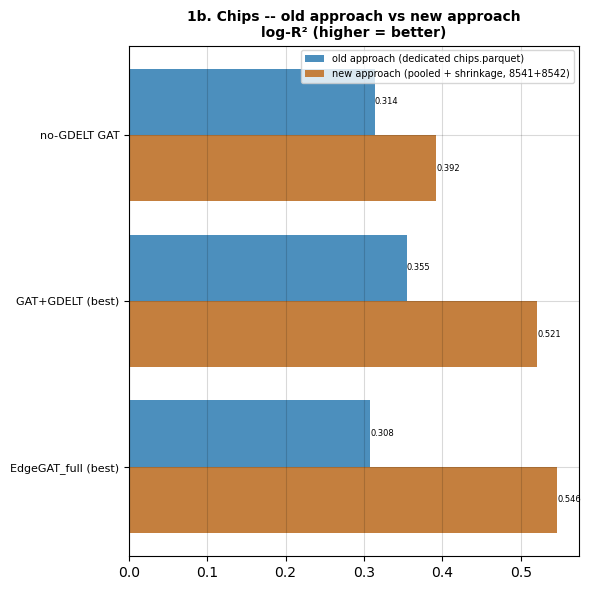

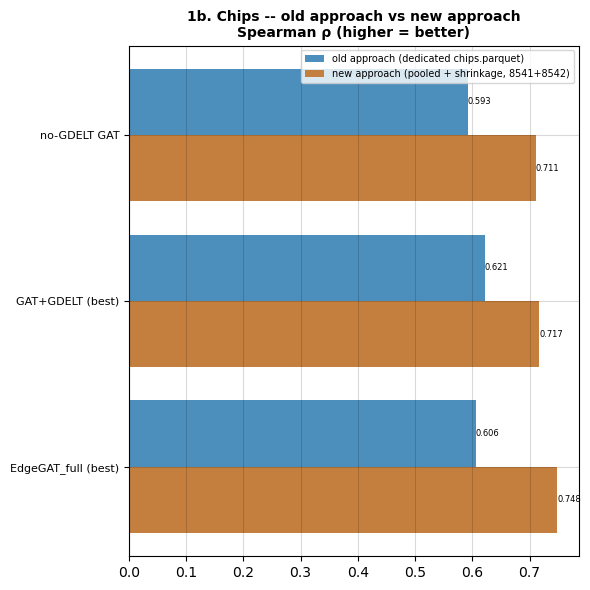

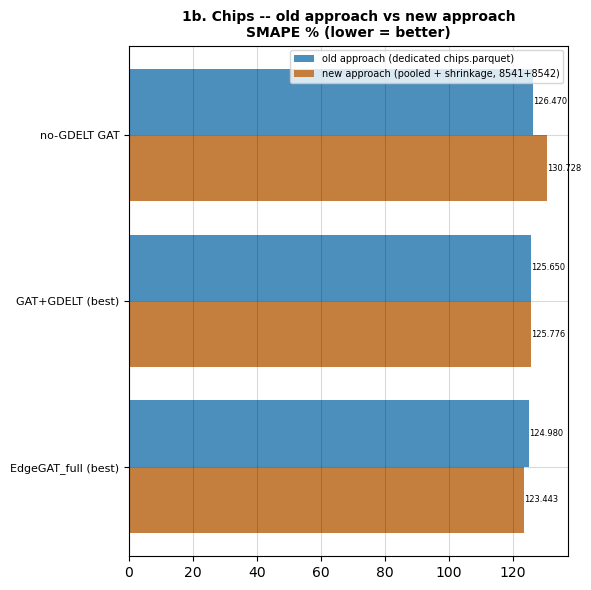

In [13]:
combo_rows = shrink[shrink.scope == 'HS_8541_8542_combined'].copy()
parsed = combo_rows['model'].apply(parse_shrinkage_name)
combo_rows['pmodel']   = [p[0] for p in parsed]
combo_rows['pscoring'] = [p[2] for p in parsed]

def bucket_metrics(df, model_col, scoring_col, metric):
    no_gdelt  = df[(df[model_col]=='GAT') & (df[scoring_col]=='none')][metric]
    gat_gdelt = df[(df[model_col]=='GAT') & (df[scoring_col]!='none')][metric]
    edge      = df[df[model_col]=='EdgeGAT_full'][metric]
    best = (lambda s: s.min()) if metric == 'smape' else (lambda s: s.max())
    return {'no-GDELT GAT': best(no_gdelt) if len(no_gdelt) else np.nan,
            'GAT+GDELT (best)': best(gat_gdelt) if len(gat_gdelt) else np.nan,
            'EdgeGAT_full (best)': best(edge) if len(edge) else np.nan}

bucket_index_1b = ['no-GDELT GAT', 'GAT+GDELT (best)', 'EdgeGAT_full (best)']
series_1b = {
    'old approach (dedicated chips.parquet)': {m: pd.Series(bucket_metrics(chips, 'model', 'scoring', m)).reindex(bucket_index_1b) for m in ['log_r2','spearman','smape']},
    'new approach (pooled + shrinkage, 8541+8542)': {m: pd.Series(bucket_metrics(combo_rows, 'pmodel', 'pscoring', m)).reindex(bucket_index_1b) for m in ['log_r2','spearman','smape']},
}
plot_metric_mosaic(bucket_index_1b, series_1b, metrics=['log_r2','spearman','smape'], metric_labels=METRIC_LABELS,
                    title_prefix='1b. Chips -- old approach vs new approach', value_fmt='{:.3f}')

buckets_chips_compare = pd.DataFrame({
    'old approach (dedicated chips.parquet)': series_1b['old approach (dedicated chips.parquet)']['log_r2'],
    'new approach (pooled + shrinkage, 8541+8542)': series_1b['new approach (pooled + shrinkage, 8541+8542)']['log_r2'],
})
buckets_chips_compare

## 7. Log-R² vs log-MSE — do the two evaluation metrics agree?

Everything above uses log-R². `recompute_full_metrics.py` was extended to also report
`log_mse` (computed directly in log1p-space, never routed through `expm1` -- so it can't
blow up from exponentiation overflow the way raw-scale MSE can; see the retraining
diagnostics work for why that matters). Worth checking whether log-MSE tells the same
story -- if a model looks good on log-R² but bad on log-MSE (or vice versa), that's worth
knowing before leaning on either metric alone in the paper.

Spearman correlation between the two rankings: 1.000
Largest rank disagreement: GAT_first_topk_blend_shrinkage (|Δrank|=0)


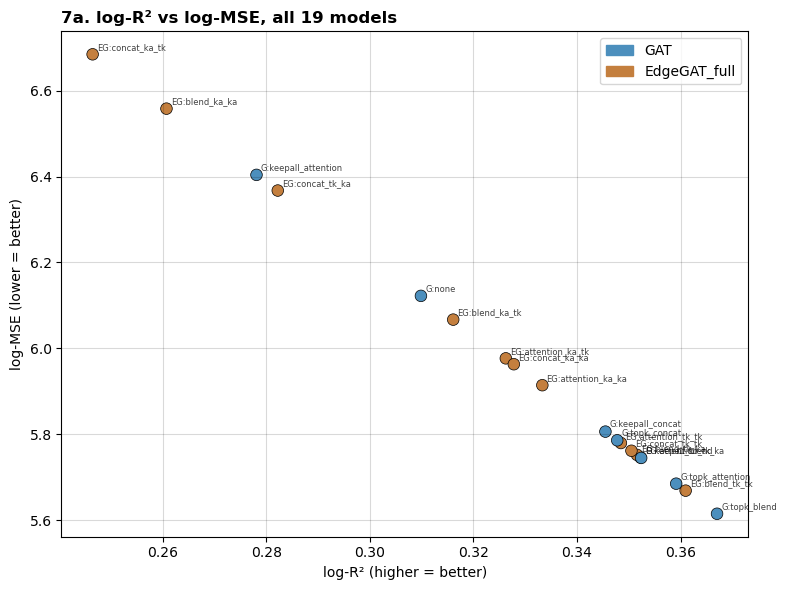

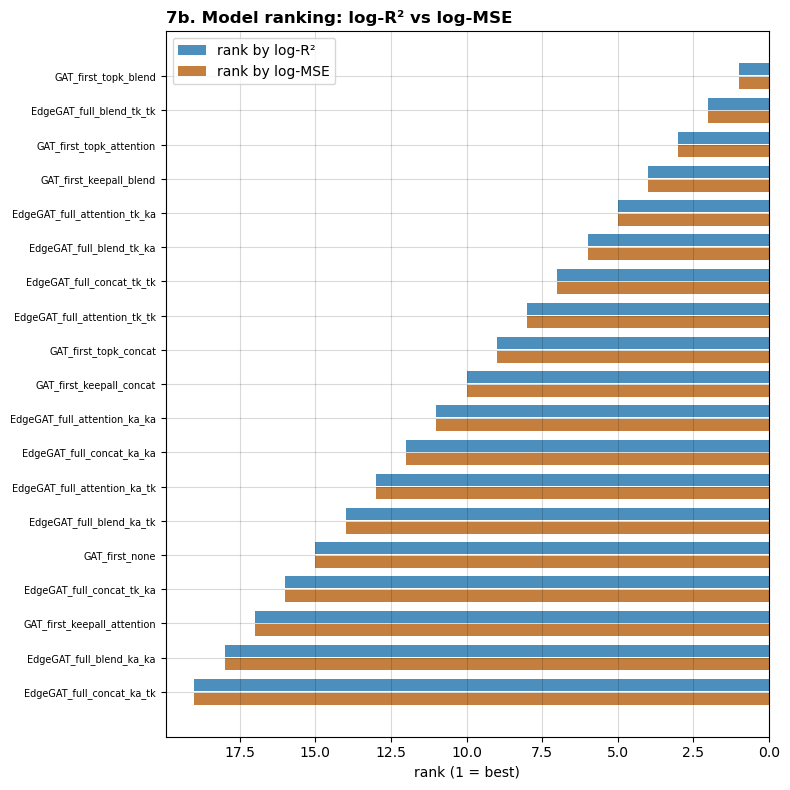

In [14]:
import os

full_metrics_path = GRIDS + 'results_shrinkage_full_metrics.csv'
if os.path.exists(full_metrics_path):
    full = pd.read_csv(full_metrics_path).set_index('model')
    full['is_edgegat'] = full.index.str.startswith('EdgeGAT_full')

    fig, ax = plt.subplots(figsize=(8, 6))
    colors_fm = [ORANGE if e else BLUE for e in full['is_edgegat']]
    ax.scatter(full['log_r2'], full['log_mse'], c=colors_fm, s=70, edgecolor='black', linewidth=0.5)
    for name, row in full.iterrows():
        label = name.replace('_shrinkage', '').replace('EdgeGAT_full_', 'EG:').replace('GAT_first_', 'G:')
        ax.annotate(label, (row['log_r2'], row['log_mse']), fontsize=6, alpha=0.75,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('log-R\u00b2 (higher = better)'); ax.set_ylabel('log-MSE (lower = better)')
    ax.set_title('7a. log-R\u00b2 vs log-MSE, all 19 models', loc='left', fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=BLUE, label='GAT'), Patch(color=ORANGE, label='EdgeGAT_full')])
    fig.tight_layout()

    rank_r2 = full['log_r2'].rank(ascending=False)
    rank_mse = full['log_mse'].rank(ascending=True)   # lower log_mse = better = rank 1
    rank_df = pd.DataFrame({'rank_by_log_r2': rank_r2, 'rank_by_log_mse': rank_mse}).sort_values('rank_by_log_r2')
    y = np.arange(len(rank_df))
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.barh(y - 0.2, rank_df['rank_by_log_r2'], 0.35, label='rank by log-R\u00b2', color=BLUE)
    ax.barh(y + 0.2, rank_df['rank_by_log_mse'], 0.35, label='rank by log-MSE', color=ORANGE)
    ax.set_yticks(y); ax.set_yticklabels([n.replace('_shrinkage', '') for n in rank_df.index], fontsize=7)
    ax.invert_yaxis(); ax.invert_xaxis()
    ax.set_xlabel('rank (1 = best)'); ax.legend()
    ax.set_title('7b. Model ranking: log-R\u00b2 vs log-MSE', loc='left', fontweight='bold')
    fig.tight_layout()

    rank_disagreement = (rank_df['rank_by_log_r2'] - rank_df['rank_by_log_mse']).abs()
    corr = rank_df['rank_by_log_r2'].corr(rank_df['rank_by_log_mse'], method='spearman')
    print(f"Spearman correlation between the two rankings: {corr:.3f}")
    print(f"Largest rank disagreement: {rank_disagreement.idxmax()} (|\u0394rank|={rank_disagreement.max():.0f})")
else:
    print(f'[skip] {full_metrics_path} not found -- run recompute_full_metrics.py first.')

## 8. Retraining variants — log-MSE view (gravity-edge & partial-pair/simplified)

Companion to `feature_importance_analysis.ipynb`'s Sections 7-9, which do this in more
depth with the canonical-original comparison. Here: just log-MSE side by side with
log-R² for the two variant families that could be recomputed. **Pruned isn't included** --
its per-model kept-column list depends on `feature_importance_shrinkage.csv` at the exact
values it had when those particular models were trained, and that file has since been
regenerated with different importance scores, so the reconstruction doesn't match the
saved weights anymore.

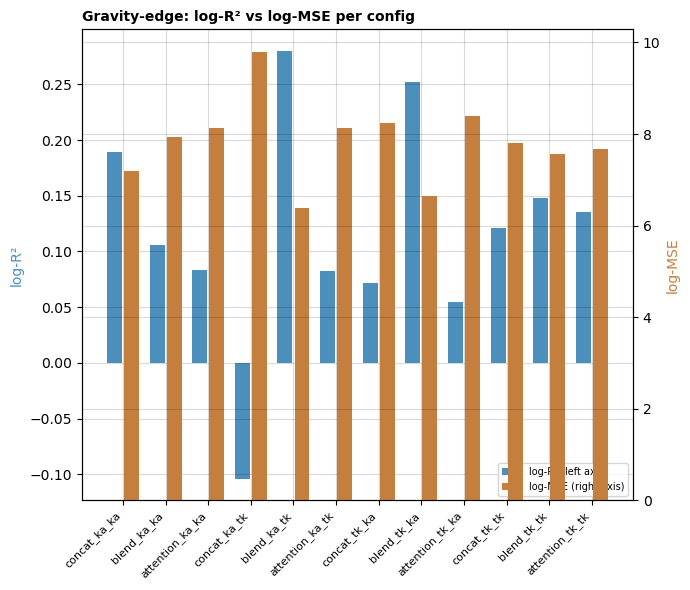

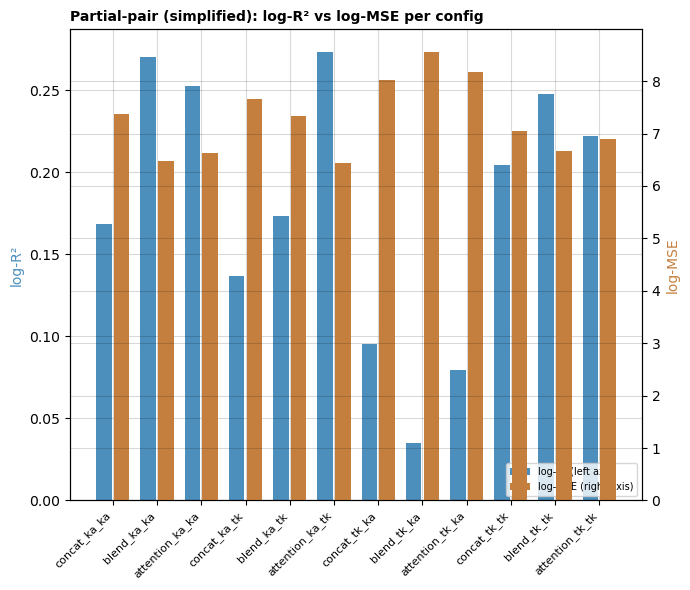

In [15]:
variant_files = {
    'Gravity-edge': GRIDS + 'results_gravity_edge_full_metrics.csv',
    'Partial-pair (simplified)': GRIDS + 'results_partial_pair_edgegat_full_metrics.csv',
}
loaded_variants = {}
for label, path in variant_files.items():
    if os.path.exists(path):
        loaded_variants[label] = pd.read_csv(path, index_col=0)
    else:
        print(f'[skip] {label} -- {path} not found')

if loaded_variants:
    for label, df in loaded_variants.items():
        fig, ax = plt.subplots(figsize=(7, 6))
        x = np.arange(len(df))
        ax2 = ax.twinx()
        ax.bar(x - 0.2, df['log_r2'], 0.35, color=BLUE, label='log-R\u00b2 (left axis)')
        ax2.bar(x + 0.2, df['log_mse'], 0.35, color=ORANGE, label='log-MSE (right axis)')
        ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('log-R\u00b2', color=BLUE); ax2.set_ylabel('log-MSE', color=ORANGE)
        ax.set_title(f'{label}: log-R\u00b2 vs log-MSE per config', loc='left', fontweight='bold', fontsize=10)
        h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1+h2, l1+l2, fontsize=7, loc='lower right')
        fig.tight_layout()
else:
    print('No variant full-metrics files found yet.')

,A1_log_r2,A1_code,A2_log_r2,A2_code,A3_log_r2,A3_code,A4_log_r2,A4_code
family,,,,,,,,
no-GDELT GAT,0.3140,"M-GA, no-GDELT",0.1114,"M-GA, no-GDELT",0.324593,"M-GA, no-GDELT",0.392105,"M-GA, no-GDELT"
GAT+GDELT (best),0.3546,M-GA-bt,0.0643,M-GA-ct,0.319752,M-GA-ct,0.520932,M-GA-bt
EdgeGAT_full (best),0.3083,M-EGF-b-kk,0.1692,M-EGF-b-tt,0.341239,M-EGF-a-kk,0.546469,M-EGF-b-tk


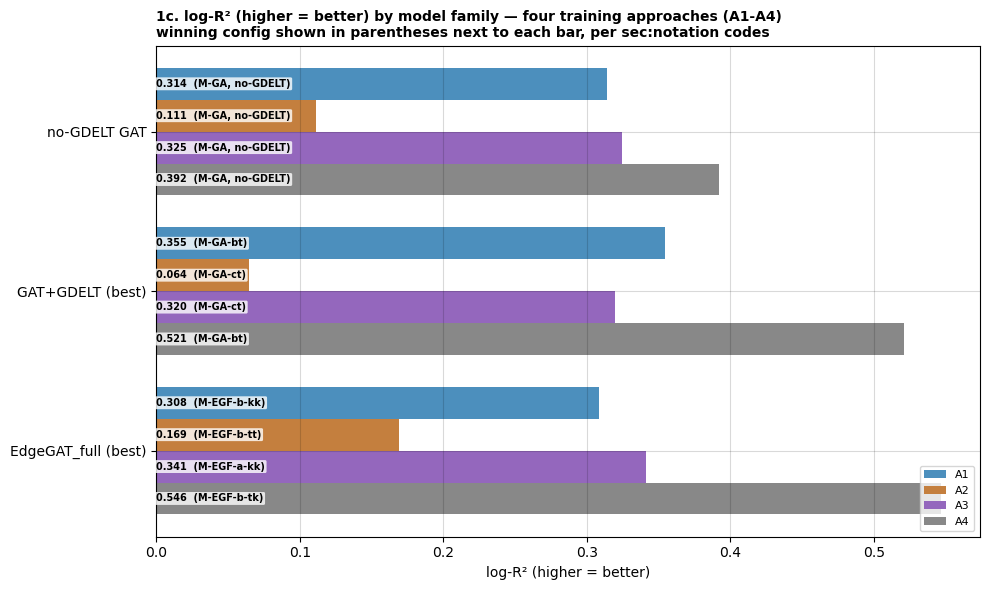

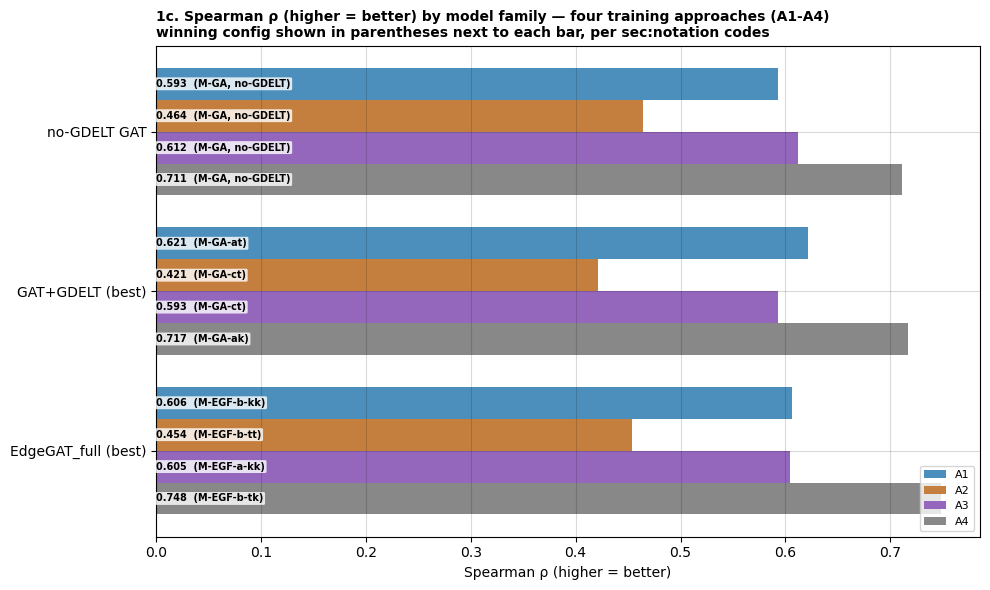

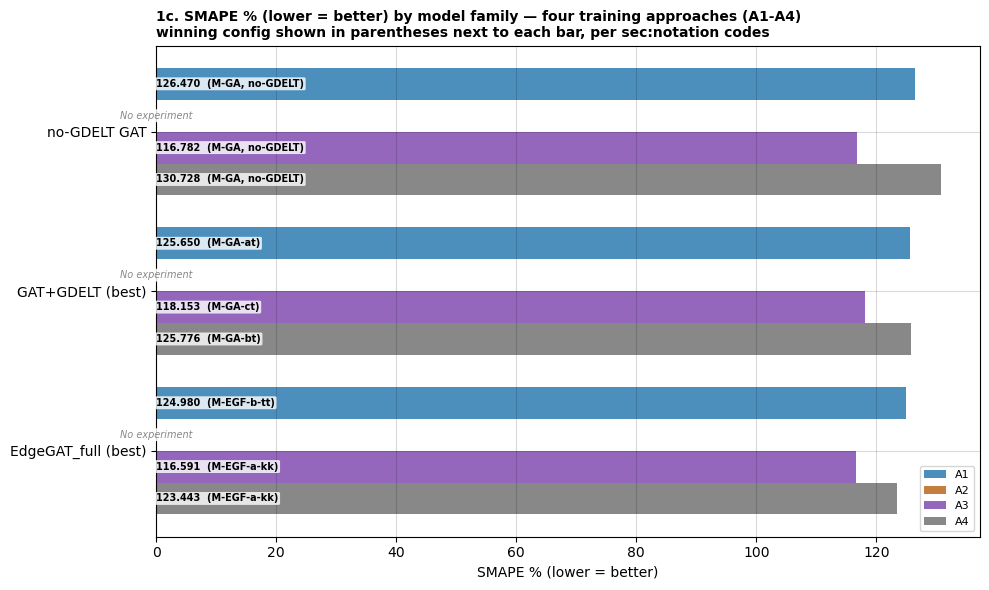

In [16]:
## 1c. Four training approaches, side by side, per model family
#
# A1 = chips.parquet only (dedicated) | A2 = all products, old / classical pooled |
# A3 = all products + per-product pooling (no shrinkage) | A4 = all products + pooling + shrinkage
#
# Each "(best)" bar is now labeled with the WINNING config's code, per the paper's
# notation table (sec:notation): M-<family>-<fusion><scoring> for single-stream models,
# M-<family>-<fusion>-<node><pair> for combined (_full) models, and "M-<family>, no-GDELT"
# for the no-GDELT baseline.

# ---- code encoder, matches sec:notation exactly ----
FAMILY_CODE  = {'GAT': 'GA', 'EdgeGAT_full': 'EGF'}
FUSION_CODE  = {'concat': 'c', 'blend': 'b', 'attention': 'a'}
SCORE_LETTER = {'keepall': 'k', 'topk': 't', 'ka': 'k', 'tk': 't'}

def encode_model_code(model, fusion, scoring):
    """scoring: 'none'/'keepall'/'topk' for GAT; a combo string like 'ka_ka' for EdgeGAT_full."""
    fam = FAMILY_CODE.get(model, model)
    if model == 'GAT':
        if scoring == 'none':
            return f'M-{fam}, no-GDELT'
        fl = FUSION_CODE.get(fusion, str(fusion)[:1])
        sl = SCORE_LETTER.get(scoring, str(scoring)[:1])
        return f'M-{fam}-{fl}{sl}'
    if model == 'EdgeGAT_full':
        fl = FUSION_CODE.get(fusion, str(fusion)[:1])
        parts = str(scoring).split('_')
        letters = ''.join(SCORE_LETTER.get(p, p[:1]) for p in parts)
        return f'M-{fam}-{fl}-{letters}'
    return f'M-{fam}'

def _pick_best(sub, metric, model_col='model', fusion_col='fusion', scoring_col='scoring'):
    """Returns (value, code) for whichever row in `sub` wins on `metric`."""
    if len(sub) == 0:
        return (np.nan, None)
    idx = sub[metric].idxmin() if metric == 'smape' else sub[metric].idxmax()
    row = sub.loc[idx]
    code = encode_model_code(row[model_col], row.get(fusion_col), row[scoring_col])
    return (row[metric], code)

FAMILY_INDEX_1C = ['no-GDELT GAT', 'GAT+GDELT (best)', 'EdgeGAT_full (best)']
_EMPTY_BUCKET = {fam: (np.nan, None) for fam in FAMILY_INDEX_1C}

def _safe(fn):
    def wrapped(metric):
        try:
            return fn(metric)
        except KeyError:
            return dict(_EMPTY_BUCKET)
    return wrapped

# ---- A1: chips.parquet -- full sweep, direct model/fusion/scoring columns ----
def bucket_chips_coded(metric):
    no_gdelt  = chips[(chips.model == 'GAT') & (chips.scoring == 'none')]
    gat_gdelt = chips[(chips.model == 'GAT') & (chips.scoring != 'none')]
    edge      = chips[chips.model == 'EdgeGAT_full']
    return {'no-GDELT GAT': _pick_best(no_gdelt, metric),
            'GAT+GDELT (best)': _pick_best(gat_gdelt, metric),
            'EdgeGAT_full (best)': _pick_best(edge, metric)}

# ---- A2: classical pooled -- only 4 rows in mvp, keyed by label string (MVP_NAMES) ----
MVP_NAMES_1C = {('GAT', 'none', 'none'): 'GAT no-GDELT',
                ('GAT', 'concat', 'topk'): 'GAT concat/topk',
                ('EdgeGAT_full', 'attention', 'ka_ka'): 'EdgeGAT_full attn/ka_ka',
                ('EdgeGAT_full', 'blend', 'tk_tk'): 'EdgeGAT_full blend/tk_tk'}
MVP_REVERSE_1C = {v: k for k, v in MVP_NAMES_1C.items()}

def bucket_classical_pooled_coded(metric):
    col = f'pooled_{metric}'
    if col not in mvp.columns:
        raise KeyError(col)
    def best_from_labels(labels):
        sub = mvp[mvp['model'].isin(labels)]
        if len(sub) == 0:
            return (np.nan, None)
        idx = sub[col].idxmin() if metric == 'smape' else sub[col].idxmax()
        row = sub.loc[idx]
        m, f, s = MVP_REVERSE_1C[row['model']]
        return (row[col], encode_model_code(m, f, s))
    return {'no-GDELT GAT': best_from_labels([MVP_NAMES_1C[('GAT', 'none', 'none')]]),
            'GAT+GDELT (best)': best_from_labels([MVP_NAMES_1C[('GAT', 'concat', 'topk')]]),
            'EdgeGAT_full (best)': best_from_labels([MVP_NAMES_1C[('EdgeGAT_full', 'attention', 'ka_ka')],
                                                      MVP_NAMES_1C[('EdgeGAT_full', 'blend', 'tk_tk')]])}

# ---- A3: per-product pooling, no shrinkage -- only 4 rows in fa_overall, keyed by FA_NAMES ----
FA_NAMES_1C = {('GAT', 'none', 'none'): 'GAT_first_none_perproduct',
               ('GAT', 'concat', 'topk'): 'GAT_first_topk_perproduct',
               ('EdgeGAT_full', 'attention', 'ka_ka'): 'EdgeGAT_full_attention_ka_ka_perproduct',
               ('EdgeGAT_full', 'blend', 'tk_tk'): 'EdgeGAT_full_blend_tk_tk_perproduct'}
FA_REVERSE_1C = {v: k for k, v in FA_NAMES_1C.items()}

def bucket_first_approach_coded(metric):
    if metric not in fa_overall.columns:
        raise KeyError(metric)
    def best_from_names(names):
        sub = fa_overall[fa_overall['model'].isin(names)]
        if len(sub) == 0:
            return (np.nan, None)
        idx = sub[metric].idxmin() if metric == 'smape' else sub[metric].idxmax()
        row = sub.loc[idx]
        m, f, s = FA_REVERSE_1C[row['model']]
        return (row[metric], encode_model_code(m, f, s))
    return {'no-GDELT GAT': best_from_names([FA_NAMES_1C[('GAT', 'none', 'none')]]),
            'GAT+GDELT (best)': best_from_names([FA_NAMES_1C[('GAT', 'concat', 'topk')]]),
            'EdgeGAT_full (best)': best_from_names([FA_NAMES_1C[('EdgeGAT_full', 'attention', 'ka_ka')],
                                                     FA_NAMES_1C[('EdgeGAT_full', 'blend', 'tk_tk')]])}

# ---- A4: pooling + shrinkage -- full sweep, pmodel/pfusion/pscoring columns ----
# NOTE: pfusion is parsed fresh from parse_shrinkage_name() here (parsed[1]) rather than
# trusting a pre-existing 'fusion' column on combo_rows -- an earlier version of this cell
# assumed that column already existed and got silent None/'N' codes when it didn't.
if 'pfusion' not in combo_rows.columns:
    _parsed_fusion_1c = combo_rows['model'].apply(lambda n: parse_shrinkage_name(n)[1])
    combo_rows = combo_rows.copy()
    combo_rows['pfusion'] = _parsed_fusion_1c

def bucket_shrinkage_coded(metric):
    no_gdelt  = combo_rows[(combo_rows.pmodel == 'GAT') & (combo_rows.pscoring == 'none')]
    gat_gdelt = combo_rows[(combo_rows.pmodel == 'GAT') & (combo_rows.pscoring != 'none')]
    edge      = combo_rows[combo_rows.pmodel == 'EdgeGAT_full']
    return {'no-GDELT GAT': _pick_best(no_gdelt, metric, 'pmodel', 'pfusion', 'pscoring'),
            'GAT+GDELT (best)': _pick_best(gat_gdelt, metric, 'pmodel', 'pfusion', 'pscoring'),
            'EdgeGAT_full (best)': _pick_best(edge, metric, 'pmodel', 'pfusion', 'pscoring')}

APPROACHES_1C = [
    ('A1', _safe(bucket_chips_coded)),
    ('A2', _safe(bucket_classical_pooled_coded)),
    ('A3', _safe(bucket_first_approach_coded)),
    ('A4', _safe(bucket_shrinkage_coded)),
]
APPROACH_COLORS_1C = [BLUE, ORANGE, PURPLE, GRAY]

def plot_four_approach_family(metric, metric_label):
    n_app = len(APPROACHES_1C)
    y = np.arange(len(FAMILY_INDEX_1C))
    h = 0.8 / n_app
    fig, ax = plt.subplots(figsize=(10, 6))
    for ai, (label, fn) in enumerate(APPROACHES_1C):
        bucket = fn(metric)
        bar_pos = y + (-0.4 + h * (ai + 0.5))
        for yp, fam in zip(bar_pos, FAMILY_INDEX_1C):
            val, code = bucket.get(fam, (np.nan, None))
            is_missing = val is None or (isinstance(val, float) and np.isnan(val))
            ax.barh(yp, 0 if is_missing else val, h, color=APPROACH_COLORS_1C[ai],
                    label=label if fam == FAMILY_INDEX_1C[0] else None)
            if is_missing:
                ax.text(0, yp, 'No experiment', va='center', ha='center', fontsize=7,
                        color=GRAY, style='italic',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
            else:
                # anchored at x=0 (the axis/zero-line), not at the bar's tip -- keeps it
                # clear of the legend regardless of bar length, and readable against any
                # bar via the white background box.
                label_txt = f'{val:.3f}' + (f'  ({code})' if code else '')
                ax.text(0, yp, label_txt, va='center', ha='left', fontsize=7,
                        fontweight='bold' if code else 'normal',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))
    ax.axvline(0, color='black', lw=.6)
    ax.set_yticks(y); ax.set_yticklabels(FAMILY_INDEX_1C)
    ax.invert_yaxis()
    ax.set_xlabel(metric_label)
    ax.set_title(f'1c. {metric_label} by model family \u2014 four training approaches (A1-A4)\n'
                 f'winning config shown in parentheses next to each bar, per sec:notation codes',
                 loc='left', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    fig.tight_layout()
    return fig

for metric, label in [('log_r2', METRIC_LABELS.get('log_r2', 'log-R\u00b2 (higher = better)')),
                       ('spearman', METRIC_LABELS.get('spearman', 'Spearman \u03c1 (higher = better)')),
                       ('smape', METRIC_LABELS.get('smape', 'SMAPE % (lower = better)'))]:
    plot_four_approach_family(metric, label)

# ---- summary table: value and winning code side by side ----
rows_1c = []
for fam in FAMILY_INDEX_1C:
    row = {'family': fam}
    for label, fn in APPROACHES_1C:
        val, code = fn('log_r2').get(fam, (np.nan, None))
        row[f'{label}_log_r2'] = val
        row[f'{label}_code'] = code if code else ('' if (val is not None and not (isinstance(val,float) and np.isnan(val))) else 'No experiment')
    rows_1c.append(row)
pd.DataFrame(rows_1c).set_index('family')